# The Bias-Variance Trade-off in Predictive Modeling

$$
E(\mathbf{Y} - A(\mathbf{Y}_n))^2 = \underbrace{\left(E[\mathbf{Y}] - E[A(\mathbf{Y}_n)]\right)^2}_{\text{Squared Bias}} + \underbrace{\mathrm{Var}(A(\mathbf{Y}_n))}_{\text{Estimation Variance}} + \underbrace{\mathrm{Var}(\mathbf{Y})}_{\text{Process Variance}}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [2]:
np.random.seed(213)

def true_function(X):
    """Defines the true underlying relationship (e.g., true risk profile)."""
    return np.cos(1.5 * np.pi * X)

def generate_data(n_samples=30):
    """Generates random data with noise, simulating real-world observations."""
    X = np.sort(np.random.rand(n_samples))
    y = true_function(X) + np.random.randn(n_samples) * 0.2
    return X, y


X_true = np.linspace(0, 1, 100)
y_true = true_function(X_true)

X_train, y_train = generate_data()

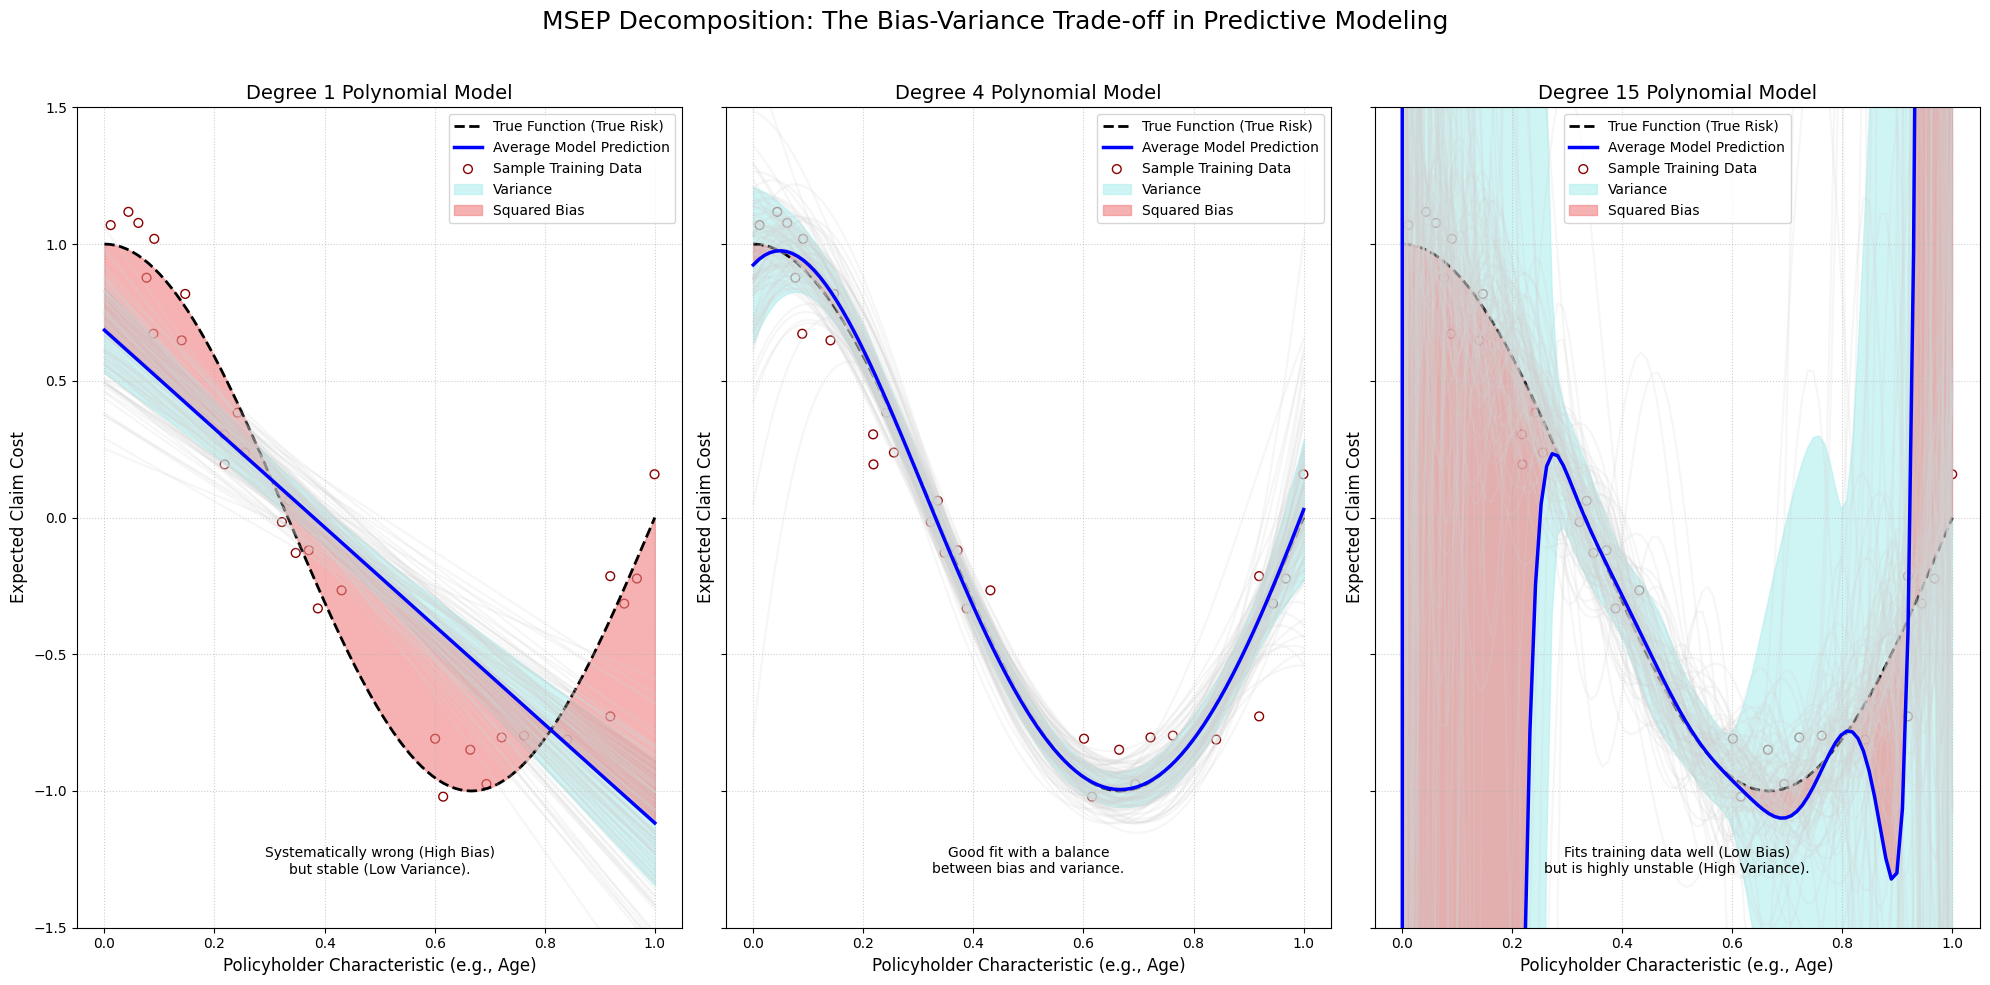

In [3]:
def plot_bias_variance_demo(ax, degree, num_simulations=100):
    """
    Fits models of a given polynomial degree to multiple simulated datasets
    to visualize bias and variance.
    """
    ax.plot(X_true, y_true, label="True Function (True Risk)", color='black', linestyle='--', linewidth=2)
    
    y_preds = np.zeros((num_simulations, len(X_true)))

    for i in range(num_simulations):
        X_sim, y_sim = generate_data()
        
        model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
        model.fit(X_sim[:, np.newaxis], y_sim)
        
        y_pred = model.predict(X_true[:, np.newaxis])
        y_preds[i, :] = y_pred
        
        ax.plot(X_true, y_pred, color='lightgray', alpha=0.2)

    avg_prediction = np.mean(y_preds, axis=0)
    squared_bias = (true_function(X_true) - avg_prediction)**2
    variance = np.mean((y_preds - avg_prediction)**2, axis=0)
    msep = squared_bias + variance 

    ax.plot(X_true, avg_prediction, label="Average Model Prediction", color='blue', linewidth=2.5)
    
    ax.scatter(X_train, y_train, s=40, facecolors='none', edgecolors='darkred', label='Sample Training Data')

    ax.fill_between(X_true, avg_prediction - np.sqrt(variance), avg_prediction + np.sqrt(variance), 
                    color='paleturquoise', alpha=0.6, label='Variance')
    ax.fill_between(X_true, true_function(X_true), avg_prediction, 
                    color='lightcoral', alpha=0.6, label='Squared Bias')

    ax.set_title(f"Degree {degree} Polynomial Model", fontsize=14)
    ax.set_xlabel("Policyholder Characteristic (e.g., Age)", fontsize=12)
    ax.set_ylabel("Expected Claim Cost", fontsize=12)
    ax.legend()
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, linestyle=':', alpha=0.6)

fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)
plt.suptitle("MSEP Decomposition: The Bias-Variance Trade-off in Predictive Modeling", fontsize=18)

# --- Model 1: High Bias, Low Variance (Underfitting) ---
# A simple model (degree 1) that fails to capture the true complexity.
plot_bias_variance_demo(axes[0], degree=1)
axes[0].text(0.5, -1.3, "Systematically wrong (High Bias)\nbut stable (Low Variance).", ha='center', fontsize=10)


# --- Model 2: Balanced Model ---
# A model (degree 4) that captures the relationship well.
plot_bias_variance_demo(axes[1], degree=4)
axes[1].text(0.5, -1.3, "Good fit with a balance\nbetween bias and variance.", ha='center', fontsize=10)

# --- Model 3: Low Bias, High Variance (Overfitting) ---
# A complex model (degree 15) that fits the noise in the data.
plot_bias_variance_demo(axes[2], degree=15)
axes[2].text(0.5, -1.3, "Fits training data well (Low Bias)\nbut is highly unstable (High Variance).", ha='center', fontsize=10)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Wnioski
---
**Model stopnia 1** wykazuje wysoki bias i niską wariancję. Linia średniej predykcji
systematycznie odbiega od prawdziwej funkcji ryzyka, a różowe pole dominuje na całym
przedziale. Model jest stabilny między symulacjami, lecz trwale błędny — w praktyce
prowadziłby do błędnej wyceny składki.

**Model stopnia 4** osiąga najlepszy balans między obydwoma składnikami MSEP. Średnia
predykcja pokrywa się z prawdziwą funkcją, a pola bias i wariancji są jednocześnie małe.
Spośród trzech modeli ten minimalizuje łączny błąd predykcji i stanowi wzorzec pożądanego
kompromisu.

**Model stopnia 15** redukuje bias kosztem ekstremalnej wariancji. Na krańcach przedziału
szare linie symulacji rozchodzą się drastycznie, a pole turkusowe przekracza granice wykresu.
Model overfittuje dane treningowe i generuje nieprzewidywalne predykcje dla nowych obserwacji.

**Wniosek ogólny:** minimalizacja MSEP wymaga zarządzania sumą bias² i wariancji, nie
eliminacji jednego z nich. Wyniki wizualnie potwierdzają, że optimum leży przy umiarkowanej
złożoności modelu, a dobór parametrów w praktyce powinien opierać się na cross-walidacji
lub regularyzacji.

---